In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl


import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

rc = {
    'figure.figsize': (10, 5),
    'axes.facecolor': 'white',
    'axes.grid': False,
    'grid.color': '.8',
    'font.family': 'Arial',
    'font.size': 12,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True,
    'axes.spines.bottom': True
}

plt.rcParams.update(rc)

In [9]:
df = pd.read_excel("final_MAG_abundance_with_taxonomy.xlsx")
df.head()


,MAG ID,Domain,Phylum,Class,Order,Family,Genus,Mean Relative Abundance (%),Completeness (%),Contamination (%),Included in Community Model
0,Gb1bin16,Bacteria,Desulfobacterota_D,UBA1144,RKRQ01,RKRQ01,RKRQ01,1.620797,93.22,0.84,Yes
1,Gb1bin17,Bacteria,Tectomicrobia,Entotheonellia,Entotheonellales,Entotheonellaceae,G958295825,1.359183,92.40,1.71,Yes
2,Gb1bin20,Bacteria,Nitrospirota,Nitrospiria,Nitrospirales,UBA8639,Bin75,2.454909,85.93,1.82,Yes
3,Gb1bin43,Bacteria,Chloroflexota,Dehalococcoidia,SAR202,UBA11138,Bin90,2.336542,79.87,0.00,Yes
4,Gb2bin20,Bacteria,Pseudomonadota,Alphaproteobacteria,UBA828,UBA828,WTGU01,2.092037,89.50,0.53,Yes


In [10]:
df.columns

Index(['MAG ID', 'Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus',
       'Mean Relative Abundance (%)', 'Completeness (%)', 'Contamination (%)',
       'Included in Community Model'],
      dtype='object')

In [11]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,Mean Relative Abundance (%),Completeness (%),Contamination (%)
count,14.000000,14.000000,14.000000
mean,2.265936,90.107143,0.765000
std,1.356000,6.353903,0.955283
min,1.040150,77.350000,0.000000
25%,1.643235,86.597500,0.000000
50%,2.009490,91.175000,0.510000
75%,2.425317,94.525000,0.940000
max,6.565234,99.510000,3.300000


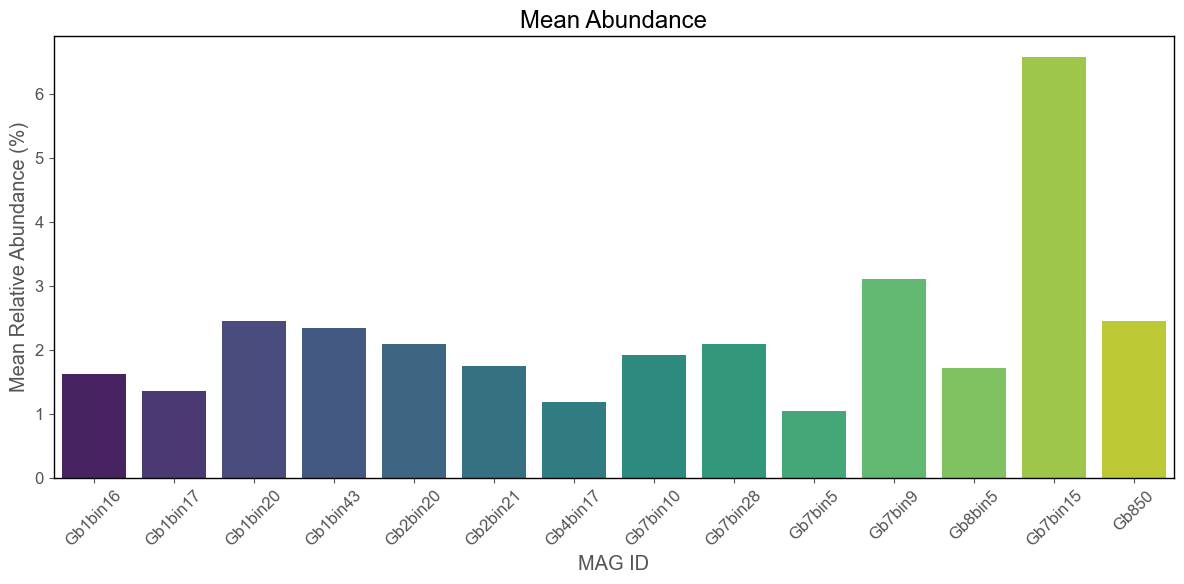

In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(x="MAG ID", y="Mean Relative Abundance (%)", data=df, palette="viridis")
plt.title("Mean Abundance")
plt.xlabel("MAG ID")
plt.ylabel("Mean Relative Abundance (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


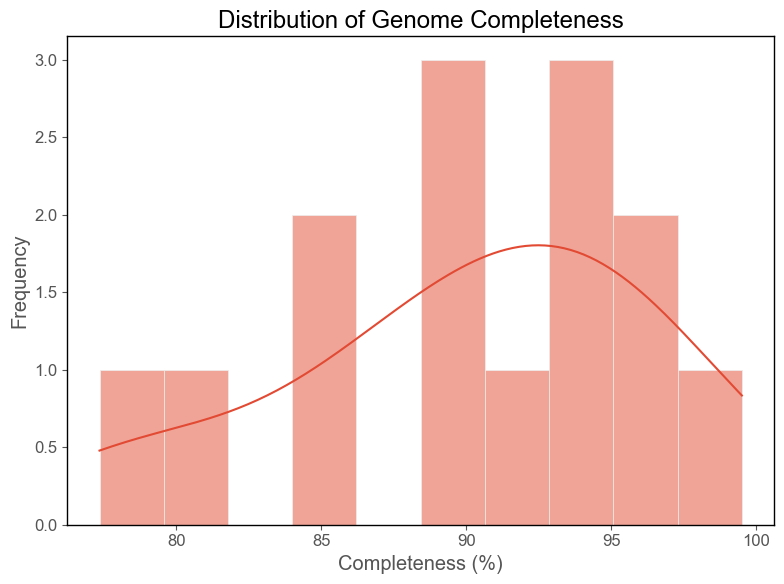

In [20]:
plt.figure(figsize=(8, 6))
sns.histplot(df["Completeness (%)"], bins=10, kde=True)
plt.title("Distribution of Genome Completeness")
plt.xlabel("Completeness (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


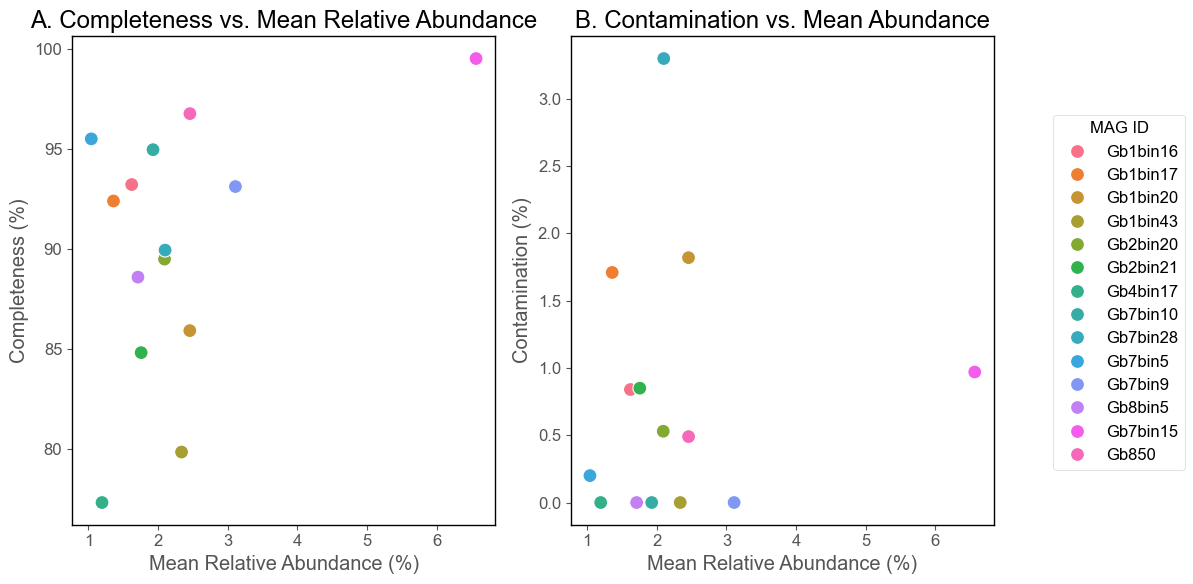

In [21]:


fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

sns.scatterplot(
    x="Mean Relative Abundance (%)",
    y="Completeness (%)",
    data=df,
    s=100,
    hue="MAG ID",
    ax=axes[0],
    legend=False
)

sns.scatterplot(
    x="Mean Relative Abundance (%)",
    y="Contamination (%)",
    data=df,
    s=100,
    hue="MAG ID",
    ax=axes[1],
    legend=True
)

axes[0].set_title("A. Completeness vs. Mean Relative Abundance")
axes[0].set_xlabel("Mean Relative Abundance (%)")
axes[0].set_ylabel("Completeness (%)")

axes[1].set_title("B. Contamination vs. Mean Abundance")
axes[1].set_xlabel("Mean Relative Abundance (%)")
axes[1].set_ylabel("Contamination (%)")

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="MAG ID", loc="center right")

axes[1].legend_.remove()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

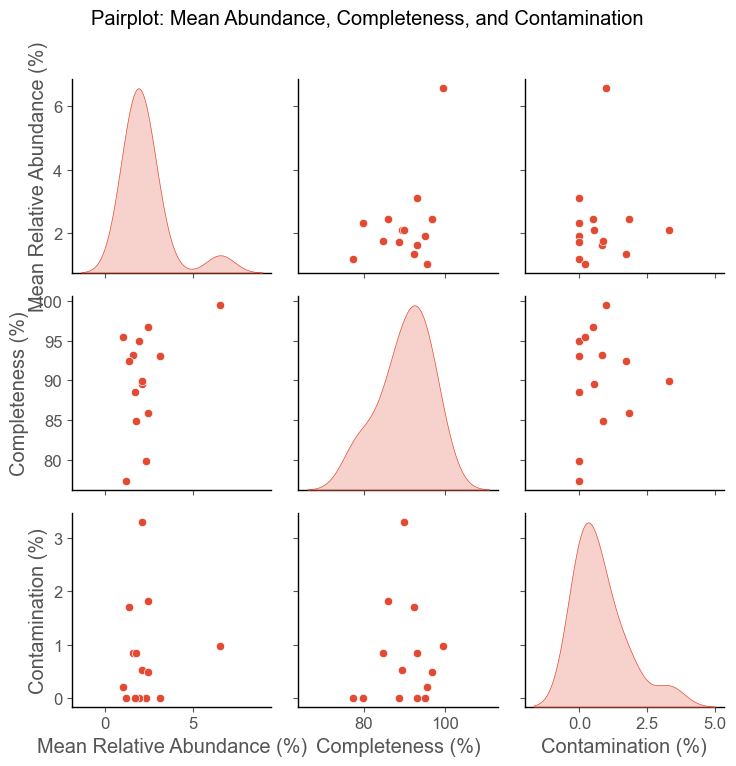

In [19]:
## Visualization 5: Pairplot for Key Variables
# Visualizes the relationships among Mean abundance, Completeness, and Contamination
selected_cols = ["Mean Relative Abundance (%)", "Completeness (%)", "Contamination (%)"]
sns.pairplot(df[selected_cols], diag_kind="kde", height=2.5)
plt.suptitle("Pairplot: Mean Abundance, Completeness, and Contamination", y=1.02)
plt.tight_layout()
plt.show()